# TP1 Algèbre : Chiffrement polygraphique (2h)

<u>***Un compte rendu est à déposer sur e-campus à la fin de la séance***</u>. *Il doit être rédigé directement dans ce document avec votre code que vous pourrez executer à partir de ce fichier section par section.*

*Il vous est demandé de montrer les résultats, de les analyser et les interpréter tout en répondant aux questions. Nous jugerons vos capacités à comprendre et interpréter mathématiquement les réalisations.*

**Assurez-vous toujours de la lisibilité des graphiques : intitulés des axes, légende, échelle, etc.**

<u>***Avant de rendre votre travail :***</u>
* ✅ *Exécutez toutes les cellules*
* ✅ *Assurez vous que tous vos résultats/figures sont bien visibles*
* ✅ *Exportez le fichier en format **pdf***
* ✅ *Déposez le **pdf** sur e-campus*

In [276]:
import numpy as np
import matplotlib.pyplot as plt

🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹

## 1- 📌 Principe

Les méthodes de chiffrement dites polygraphiques procèdent au chiffrement d'un message par paquets de $n$ lettres en utilisant une clé de $n$x$n$ nombres. 

Pour comprendre le principe, prenons le cas simple où $n=2$, on parle alors de chiffrement diagraphique. 

On associe d'abord à chaque lettre de l'alphabet, un code numérique, qui est, par exemple, un nombre compris entre 0 et 25 pour les 26 lettres majuscules :   

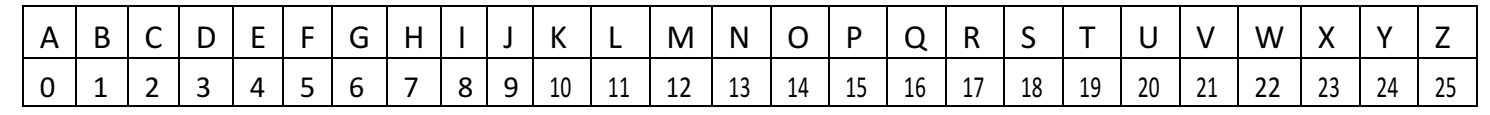

On se donne ensuite quatre nombres (a, b, c, d), bien choisis, qui constitueront la "clé" du chiffrement. 

Soit $x_1$ et $x_2$  les codes numériques associés aux deux premières lettres du mot à chiffrer. On en déduit les codes  $y_1$ et $y_2$  des deux lettres correspondantes dans le mot chiffré par l'opération suivante :  

$ y_1 = a x_1 + b x_2 \\
 y_2 = c x_1 + d x_2 $

Si les codes $y_1$ et $y_2$ ainsi obtenus ne sont pas compris entre 0 et 25, on les remplace par leur valeur   $y'_1$ et $y'_2$  modulo 26 c'est-à-dire que l'on soustrait autant de fois que nécessaire la valeur 26 au code s'il est positif, ou on lui ajoute autant de fois que nécessaire la valeur 26 s'il est négatif, afin d'obtenir un nombre compris entre 0 et 25. Autrement dit on le remplace par le reste de sa division par 26.

Il ne reste plus qu'à chercher dans la table des codes à quelles lettres correspondent ces deux codes $y'$ finaux, puis de recommencer la procédure pour tous les autres "paquets" de deux lettres suivants du mot à chiffrer, et ainsi obtenir le mot complet chiffré.  

**Exemple**: chiffrement du mot "*TP*" avec la clé (3,-2,-1,1)  
* On code les lettres du mot à l'aide de la table de correspondance : T => 19 = $x_1$ et P => 15 = $x_2$
* On chiffre ces deux codes : <br>
  $y_1 = 3*19 -2*15 = 27 \\
  y_2 = -19 + 15 = -4 $

On remarque que 27 n'est pas un code "valide" (non compris entre 0 et 25), donc on le ramène à 1 en lui retranchant 26. De la même façon on ramène le -4 à 22 en lui rajoutant 26 .

Le mot "*TP*" chiffré est donc finalement décrit par les codes  $y'_1=1$ et $y'_2=22$   , soit le mot "*BW*"  

🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹

## 2- 🧮 Formalisation

### ✏️ 2.1 Ecriture matricielle (2pts)

Écrivez sous forme matricielle l'opération de chiffrement, permettant de passer des codes de départs $x_1$ et $x_2$  aux codes chiffrés $y_1$ et $y_2$ . On ne tiendra pas compte des éventuels modulo 26 dans cette écriture.


$\begin{pmatrix}
y_1 \\
y_2
\end{pmatrix}$ =
$\begin{pmatrix}
a & b \\
c & d
\end{pmatrix}$ *
$\begin{pmatrix}
x_1 \\
x_2
\end{pmatrix}$

En déduire l'opération inverse de déchiffrement sous forme matricielle. 

$\begin{pmatrix}
x_1 \\
x_2
\end{pmatrix}$ =
$\frac{1}{ad - bc}$
$\begin{pmatrix}
d & -b \\
-c & a
\end{pmatrix}$ * 
$\begin{pmatrix}
y_1 \\
y_2
\end{pmatrix}$

❓Quelle condition nécessaire doivent respecter les nombres choisis pour la clé afin que le décryptage soit possible ?

Il faut que la clé soit inversible, c'est-à-dire que $ad-bc \neq 0$.

### 🔐 2.2 Exemple de chiffrement (3pts)

Chiffrez le mot "POLYTECH" avec la clé (2,3,1,1). Remplissez pour cela le tableau ci-dessous en faisant le calcul matriciel sous Python. Pour le calcul du modulo vous pouvez utiliser l'opérateur `%`.

In [277]:
#*******************************************************************************
# écrire ci-dessous un code qui calcule y' étant donné x pour vous aider à remplir
# le tableau
#*******************************************************************************
x1 = 2
x2 = 7
x = np.array([x1 ,x2])

#-----------------------------------------------------------------------------
# définir la matrice clé
cle = np.array([[2, 3], [1, 1]])

#-----------------------------------------------------------------------------
# calculez y' en faisant l'opération matricielle et le modulo
print('x', x)

y = np.dot(cle, x)
print('y', y)

modulo = lambda t: t % 26
yprime = np.array([modulo(yi) for yi in y])
print("y'", yprime)

x [2 7]
y [25  9]
y' [25  9]


| | P  | O | L | Y | T | E | C | H |
|------------|------------|------------|------------|------------|------------|------------|------------|------------|
| **Code lettre (x)**    | 15  | 14    |11    | 24   | 19  | 4  | 2   |7  |
| **Code crypté (y)**     | 72  | 29    |94    | 35   | 50  | 23  | 25   |9  |
| **Code modulo 26 (y')**    | 20  | 3    |16    | 9   | 24  | 23  | 25   |9  |
| **Mot crypté**    | U  | D    |Q    | J   | Y  | X  | Y   |J  |


### 🔓 2.3 Exemple de déchiffrement (3pts)

Décryptez le mot "KFCKIP" avec la même clé qu'à la question précédente. Remplissez pour cela un tableau similaire à celui utilisé pour le cryptage, en explicitant de même les opérations à faire sur chaque ligne.  

In [278]:
#*******************************************************************************
# écrire ci-dessous un code qui remonte à x étant donné y pour vous aider à
# décrypter paquet par paquet
#*******************************************************************************

y1 = 8
y2 = 15
y = np.array([y1 ,y2])

# clé inverse
cle_inverse = np.linalg.inv(cle)

x = np.dot(cle_inverse, y)
print("x", x)

xprime = np.array([modulo(xi) for xi in x])
print("x'", xprime)


x [ 37. -22.]
x' [11.  4.]


| | K  | F | C | K | I | P |
|------------|------------|------------|------------|------------|------------|------------|
| **Code lettre (y)**    | 10  | 5    |2    | 10   | 8  | 15  |
| **Code décrypté (x)**     | 5  | 0    |28    | -18   | 37  | -22  | 
| **Code modulo 26 (x')**    | 5  | 0    |2    | 8   | 11  | 4  | 
| **Mot décrypté**    | F  | A    |C    | I   | L  | E  | 


🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹

## 3-🔐 Chiffrage / déchiffrage

### 🔢🔒 3.1 Chiffrer un code (3.5pts)

🧩Écrivez une fonction `chiffrerCode` qui admet en entrée un vecteur de codes lettres (les x) et une matrice "clé", et renvoie le vecteur des y' correspondants.

In [279]:
def chiffrerCode (x, cle) :
    #*******************************************************************************
    # écrire ci dessous le code qui chiffre le vecteur x avec la clé et retourne crypt
    # (crypt c'est les y' après calcul du modulo)
    #******************************************************************************
        
    # Astuce ---------------------------------------------------------------------- 
    # On pourrait utiliser la fonction reshape pour réarranger le vecteur d'entrée 
    # en paquets et pouvoir traiter le mot paquet par paquet.
    # Par exemple np.reshape(x, (-1, 2)).T permet de  transformer le vecteur x 
    # en une matrice de 2 x nombre de paquets
    
    #-----------------------------------------------------------------------------
    # commencez pas appeler reshape correctement pour mettre en forme votre vecteur x
    x_arranged = np.reshape(x, (-1, len(cle))).T   
    
    #-----------------------------------------------------------------------------
    # calculez ensuite le code y' et stockez le dans crypt
    # aucune boucle n'est nécessaire. 
    
    y = np.dot(cle, x_arranged)

    #-----------------------------------------------------------------------------
    # redimensionnez à la fin de sorte que crypt ait les mêmes dimensions
    # que x. On pourrait faire crypt.T.flatten()
    

    crypt = y % 26
    crypt = crypt.T.flatten()

    return crypt


 ✔️Testez la fonction avec la clé (2,3,1,1) et le mot "POLYTECH" en code lettre (programme ci-dessous). Si votre fonciton est correcte, vous devriez voir  s'afficher :  [20   3   16   9   24   23   25   9 ]

In [280]:
#*******************************************************************************
# code qui teste votre fonction chiffrer
#******************************************************************************
x = np.array([15,14,11,24,19,4,2,7])
cle = np.array([[2, 3],[1, 1]])
y = chiffrerCode(x,cle)
print(y)


[20  3 16  9 24 23 25  9]


### 🔓🔢 3.2 Déchiffrer un code (1pt)

🧩Écrivez une fonction `dechiffrerCode`qui admet en entrée un vecteur de codes chiffrés (les y') et une matrice "clé", et renvoie le vecteur des codes x correspondants.

In [281]:
def dechiffrerCode (y, cle) :
    #-----------------------------------------------------------------------------
    # Utilisez la fonction chiffrerCode avec la bonne clé pour déchiffrer
    cle_inverse = np.linalg.inv(cle)
    decrypt = chiffrerCode(y, cle_inverse)
    return decrypt

✔️ Testez la fonction avec la clé (2,3,1,1) et le code obtenu à la question 3.1 (programme ci-dessous).   Si votre fonciton est correcte, vous devriez voir  s'afficher :  [15  14  11  24  19  4  2  7  ]

In [282]:
#*******************************************************************************
# code qui teste votre fonction déchiffrer
#******************************************************************************
y = np.array([20,3,16,9,24,23,25,9])
cle = np.array([[2, 3],[1, 1]])
x = dechiffrerCode(y,cle)
print(x)

[15. 14. 11. 24. 19.  4.  2.  7.]


### 📝🔒📝 3.3 Chiffrer et déchiffrer des mots en toutes lettres (1.5pt)

🧩Écrivez les fonctions `chiffrer` et `dechiffrer` de sorte à admettre le mot en toute lettre directement en argument et renvoyer respectivement le mot chiffré et déchiffré.  

In [283]:
def chiffrer(mot, cle):
    #*******************************************************************************
    # écrire ci dessous le code qui chiffre un mot avec la cle donnée
    #******************************************************************************
    
    #-----------------------------------------------------------------------------
    # On doit transformer d'abord le vecteur mot en un vecteur code pour pouvoir
    # utiliser chiffrerCode définie précédemment
    code =[]
    
    # Une façon simple pour faire la correspondance entre lettre et code 
    # serait de définir une chaine de  caractère
    alphabet = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ';
    
    #on boucle ensuite sur le mot pour retrouver l'indice de chaque lettre et construire
    #le vecteur code 
    code = np.array([alphabet.index(c) for c in mot])

    #-----------------------------------------------------------------------------
    # appelez la fonction chiffrerCode avec le vecteur code obtenu à l'étape
    # précédente pour calculer crypt
    crypt = chiffrerCode(code, cle)

    #-----------------------------------------------------------------------------
    # à partir du vecteur crypt remontez au mot 
    crypt = ''.join([alphabet[i] for i in crypt.astype(int)])
        
    return crypt

In [284]:
def dechiffrer(mot,cle):
    #*******************************************************************************
    # écrire ci dessous le code qui dechiffre un mot avec la cle donnée en utilisant
    # la fonction chiffrer précédemment définie
    #******************************************************************************

    cle_inverse = np.linalg.inv(cle)
    decrypt = chiffrer(mot, cle_inverse)

    return decrypt

✔️ Testez les fonctions avec la clé (2,3,1,1) et le mot POLYTECH. Après déchiffrement vous devriez retrouver le mot POLYTECH.

In [285]:
#*******************************************************************************
# code qui teste vos fonctions chiffrer et dechiffrer
#******************************************************************************
mot = 'POLYTECH'
cle = np.array([[2, 3],[1, 1]])
motChiff = chiffrer(mot,cle)
print(f'le mot {mot} est chiffré en tant que {motChiff}\n')

motDechiff = dechiffrer(motChiff,cle)
print(f'en déchiffrant on retrouve bien {motDechiff} \n')

le mot POLYTECH est chiffré en tant que UDQJYXZJ

en déchiffrant on retrouve bien POLYTECH 



✔️ Déchiffrer le mot mystère KFCKIP 

In [286]:
motChiffre = 'KFCKIP'
motMystere = dechiffrer(motChiffre,cle)
print(f'le mot mystère est {motMystere} \n')

le mot mystère est FACILE 



### 🔑 3.4 Chiffrer et déchiffrer avec des clés d'ordre plus élevé (1pt)

🧩 Afin de rendre le chiffrement plus complexe on peut utiliser des matrices clés de dimensions 3, 4 ou plus. Définissez une matrice de chiffrement de 3x3 telle que [[1, 2 ,4] [1, 1 ,2] [0, 1 ,1] ]. Testez-la avec les fonctions chiffrer et dechiffrer programmées précédemment. Si vos fonctions sont bien définies aucune modification du code est nécessaire pour passer à des dimensions supérieures.

In [287]:
#*******************************************************************************
# écrire ci dessous un code qui teste vos fonctions chiffrer et dechiffrer avec une 
# clé 3x3
#******************************************************************************

mot = 'JORDNA'
cle = np.array([[1, 2, 4],[1, 1, 2],[0, 1, 1]])
motChiff = chiffrer(mot,cle)
print(f'le mot {mot} est chiffré en tant que {motChiff}\n')

motDechiff = dechiffrer(motChiff,cle)
print(f'en déchiffrant on retrouve bien {motDechiff} \n')


le mot JORDNA est chiffré en tant que BFFDQN

en déchiffrant on retrouve bien JORDNA 



🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹

## 4- 📊 Effet sur la structure statistique du texte (4pts)

Dans une langue donnée, certaines lettres apparaissent beaucoup plus fréquemment que d’autres donnant une distribution statistique spécifique. 

🧩 Exécutez le code ci dessous pour visualiser la distribution statique de deux textes, un en français et un en anlglais.

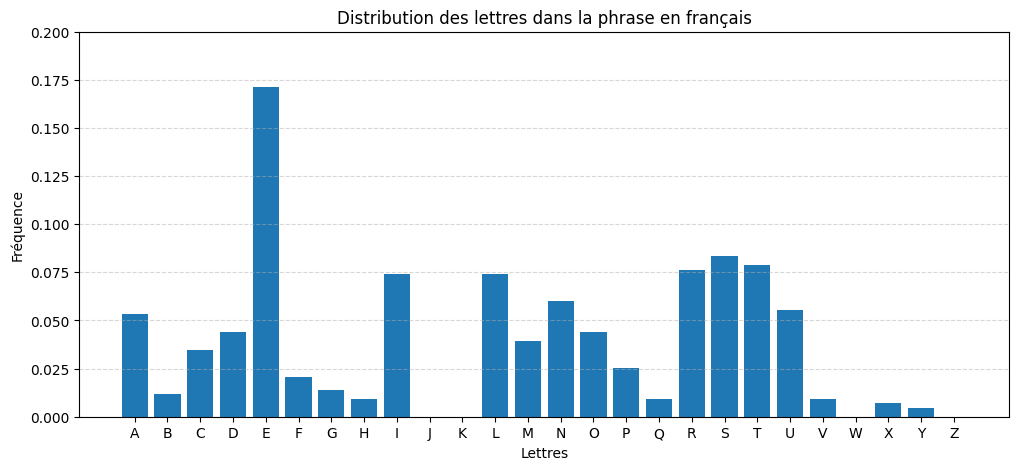

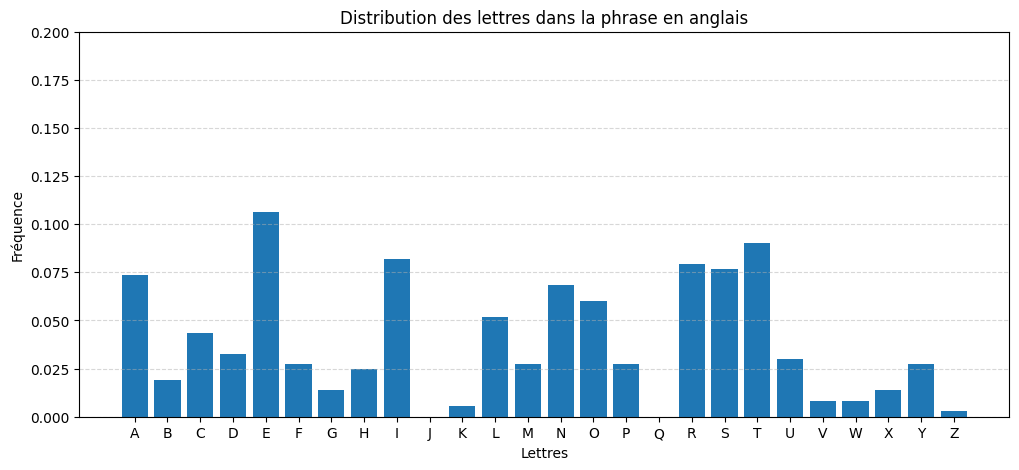

In [288]:
phrase =  'ALGEBRELINEAIREMODULAIRECRYPTOGRAPHEHILLPERMETDECOMPRENDRELIMPORTANCEDESMATRICESDESVECTEURSDELINVERSIBILITEETDELADIFFUSIONDANSLESYSTEMESDECHIFFREMENTCEEXEMPLEILLUSTRECOMMENTUNMESSAGEESTTRANSFORMEPARUNETRANSFORMATIONLINEAIREMODULOVINGTSIXETPOURQUOILATAILLEDESBLOCSINFLUENCELASECURITEDUCHIFFREMENTENPRATIQUENOUSOBSERVONSQUELESBLOCSDETAILLEPLUSGRANDEPRODUISENTUNMEILLEURMELANGEDESLETTRESETREDUISENTLESSTRUCTURESSTATISTIQUESDUTEXTECLAIR'
sentence = 'LINEARALGEBRAMODULARCRYPTOGRAPHYHILLHELPSUNDERSTANDIMPORTANCEOFMATRICESANDVECTORSINVERISIBILITYANDDIFFUSIONINSYSTEMSOFENCRYPTIONTHISEXAMPLEILLUSTRATESHOWAMESSAGEISTRANSFORMEDBYALINEARMODULOTWENTYSIXTRANSFORMATIONANDWHYBLOCKSIZESINFLUENCETHESECURITYOFENCRYPTIONINPRACTICEOBSERVELARGERBLOCKSPRODUCEABETTERMIXINGOFLETTERSANDREDUCETHESTATISTICALSTRUCTURESOFTHEPLAINTEXTX'


def letter_frequencies(text):
    alphabet = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ';
    total = len(text)

    freq = {letter: 0 for letter in alphabet}  #créer un dictionnaire dont les clés sont toutes les lettres A, B, C, …, Z et dont la valeur associée à chacune est 0.

    for c in text:
        if c in freq:
            freq[c] += 1

    for letter in freq:
        freq[letter] /= total

    return freq


def plot_frequencies(text, title):
    freq = letter_frequencies(text)

    letters = list(freq.keys())
    values = list(freq.values())

    plt.figure(figsize=(12,5))
    plt.bar(letters, values)
    plt.ylim(0, .2)
    plt.title(title)
    plt.xlabel("Lettres")
    plt.ylabel("Fréquence")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()


plot_frequencies(phrase, "Distribution des lettres dans la phrase en français")
plot_frequencies(sentence, "Distribution des lettres dans la phrase en anglais")

✏️ Interprétez les graphiques en expliquant globalement les différences

Dans la langue française, la lettre **e** apparaît énormément, au quotidien, et beaucoup de lettres sont rarement utilisées, notamment J, K, W et Z.

Cependant, dans la langue anglaise, l'utilisation des lettres est globalement homogène, et utilise presque toute les lettres (sauf la lettre J et Q). Cela témoigne que les lettres utilisées dans des phrases simples sont assez dispersés, et riche.

🧩 Le chiffrement va casser la structure statistique du texte. Pour observer cet effet, chiffrez les deux phrases avec la clé 2x2 ainsi que la clé 3x3. Tracez les histogrammes des textes chiffrés.

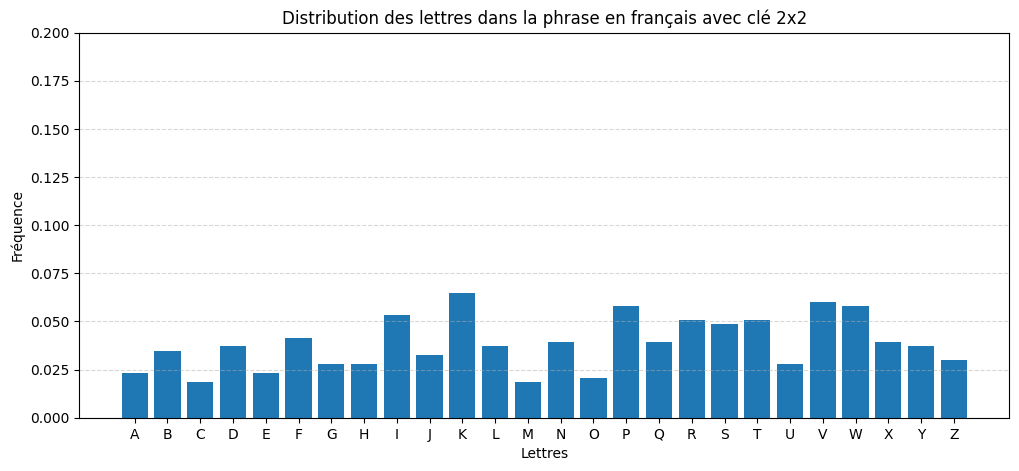

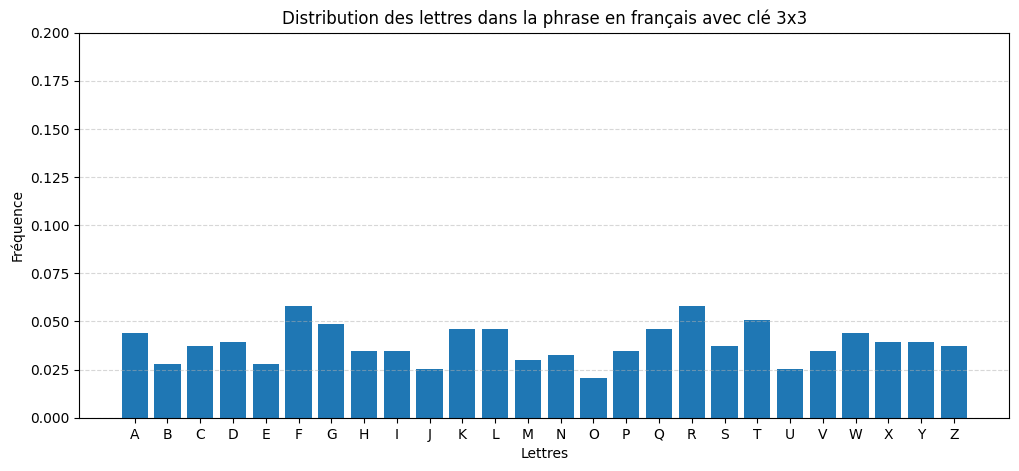

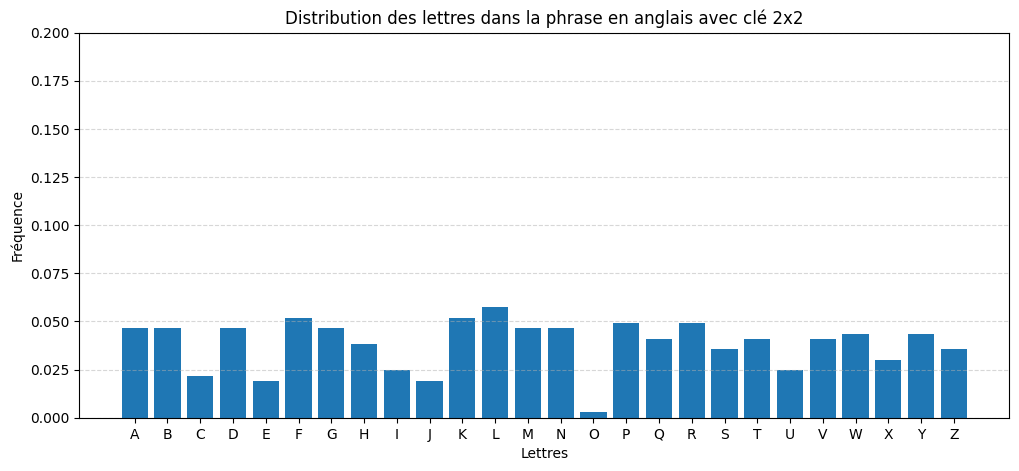

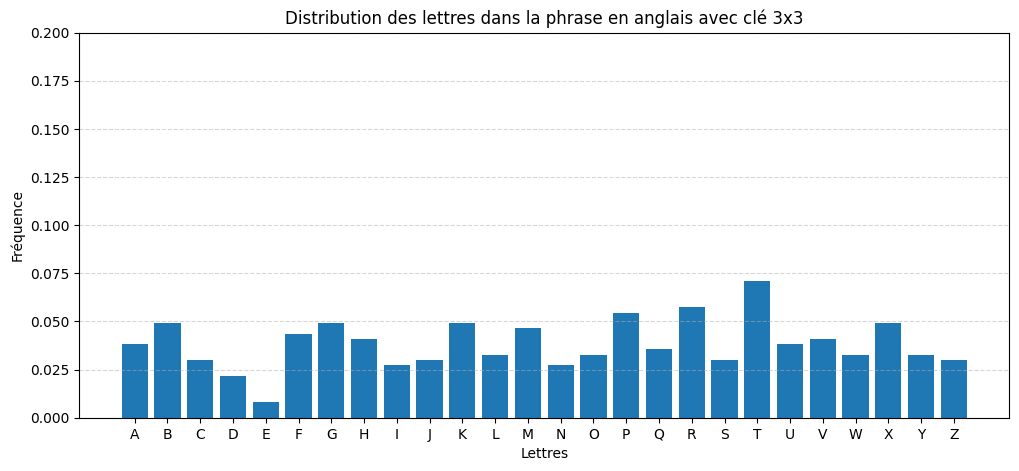

In [289]:
#*******************************************************************************
# écrire ci dessous le code qui chiffre les textes et affiches les histogrammes
#******************************************************************************

cle2 = np.array([[2, 3],[1, 1]])
cle3 = np.array([[1, 2 ,4], [1, 1 ,2] ,[0, 1 ,1] ])

#-----------------------------------------------------------------------------
# chiffrer phrase avec la clé 2x2 et la clé 3x3
# et tracez les histogrammes des textes résultants
    
chiffrement1 = chiffrer(phrase, cle2)
chiffrement2 = chiffrer(phrase, cle3)

plot_frequencies(chiffrement1, "Distribution des lettres dans la phrase en français avec clé 2x2")
plot_frequencies(chiffrement2, "Distribution des lettres dans la phrase en français avec clé 3x3")

#-----------------------------------------------------------------------------
# chiffrer sentence avec la clé 2x2 et la clé 3x3
# et tracez les histogrammes des textes résultants

chiffrement3 = chiffrer(sentence, cle2)
chiffrement4 = chiffrer(sentence, cle3)

plot_frequencies(chiffrement3, "Distribution des lettres dans la phrase en anglais avec clé 2x2")
plot_frequencies(chiffrement4, "Distribution des lettres dans la phrase en anglais avec clé 3x3")


❓Comparez aux histogrammes des textes clairs. 

On remarque avec les chiffrements de ``phrase`` et ``sentence``, que la distribution des lettres devient complètement homogène, sans laisser apparaitre de dipersion significative d'une lettre.

Cela permet donc de conclure qu'à partir du texte chiffré, nous ne pouvons pas deviner le texte initial.

🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹

## 5- 💥 Vulnérabilité du chiffrement (3pts)

Le chiffrement que nous avons étudié, connu sur le nom de chiffrement de Hill, est simple et mathémtiquement élégant, mais il est extrêmement vulnérable et structurellement fragile car il est linéaire. En effet il suffit de connaître 
$n$ paires de texte clair et chiffré pour reconstruire entièrement la clé. Pour une clé 2×2, il suffit que l'attaquant connaisse deux paires pour deviner la clé, une fois celle-ci retrouvée, tous les messages chiffrés avec cette clé peuvent être déchiffrés.

L'opération de chiffrement s'écrit :

$ C = KP (mod 26)$ 

$P$ est un vecteur colonne de taille $n$ représentant un bloc du texte clair,
$C$ est le bloc chiffré correspondant,
$K$ est la matrice clé de taille $n$x$n$

Si l'attaquant connait $n$ blocs de texte clair distincts et leurs blocs chiffrés correspondants, qu'on peut regrouper tel que:

$P=[P_1 P_2 ... P_n] , C= [C_1 C_2 ... C_n]$

où $P_i$ et $C_i$ sont des vecteurs colonne de taille $n$. Les matrices $P$ et $C$ sont donc des matrices $n$x$n$

Il peut retrouver $K$, en calculant

$K = CP^{-1} (mod 26) $

Cette forumule doit être comprise dans le cadre de l’algèbre modulaire : l’inverse $P^{-1}$ n’est pas l’inverse usuel des matrices réelles, mais un inverse modulo 26, dont le calcul dépasse le cadre de ce TP. L’essentiel à retenir est que, dès que l’on dispose de $n$ paires de blocs clair–chiffré formant une matrice $P$ inversible modulo 26, la clé $K$ peut être retrouvée de manière directe et efficace.


La solution la plus naturelle, simple et historiquement pertinente est d’introduire une substitution non linéaire de la forme :

$ C = S ( KP mod26)$ 
où S est une substitution de lettres, c'est une fonction non linéaire sur l'espace des entiers modulo 26.

En ajoutant cette étape de substitution non linéaire (une S‑box), on détruit la linéarité du chiffrement et on empêche toute reconstruction directe de la clé par algèbre matricielle.

Mathématiquement, une S‑box est une fonction bijective  *S: {0,...,25} -> {0,...,25}* qui remplace chaque lettre par une autre.

Numériquement on peut par exemple, définir S telle que :



In [290]:
S = [16,12,25,5,9,24,13,14,19,11,17,18,20,2,7,3,1,23,4,0,15,6,8,21,10,22]

dans ce cas :

A = 0 → S[0] = 16 → Q

B = 1 → S[1] = 12 → M

T = 19 → S[19] = 0 → A

Concrètement le chiffrement/ déchiffrement s'effectuera comme suit :
- Chiffrement : <large> **mot** </large>──<small>Hill</small> ──> <large>**Y**</large> ──<small>S</small>  ──> <large>**C**</large>

- Déchiffrement :  <large> **C**</large> ──<small>S⁻¹</small>──><large> **Y**</large>  ──<small>Hill⁻¹</small>──> <large>**mot**</large>

le déchiffrement nécessite donc d'inverser la substitution. On peut calculer $S_{inv}$ comme suit: 

In [291]:
# Calcul de l'inverse de la S-box
S_inv = [0]*26
for i, val in enumerate(S):
    S_inv[val] = i


🧩 Implémentez l'utilisation de la S-box. Pour cela écrivez deux fonctions :
- `chiffrer_S_box` qui reprend les étapes de chiffrement linéaire, et rajoute la subtitution appliquée au code chiffré (juste avant la transformation en lettre) tel que 
  ```python
    # Application de la S-box
    crypt_sub = np.array([S[i] for i in crypt])
    ```
- `dechiffrer_S_box` qui applique tout d'abord la S-box inverse au code correspondant au mot donné en entrée, juste avant d'effectuer le déchiffrement tel que implémenté dans la fonction `dechiffrer`
  ```python
     # Application de la S-box inverse
    code_inv = np.array([S_inv[i] for i in code])
    ```

In [292]:

def char2code(char):
    return "ABCDEFGHIJKLMNOPQRSTUVWXYZ".index(char)

def code2char(code):
    return "ABCDEFGHIJKLMNOPQRSTUVWXYZ"[int(code)]

def chiffrer_S_box(mot, cle):
    #*******************************************************************************
    # écrire ci dessous le code qui chiffre avec substitution 
    #******************************************************************************

    mot_code = np.array([char2code(char) for char in mot]) # Transformer le mot en code

    y = chiffrerCode(mot_code, cle)
    crypt_sub = np.array([S[i] for i in y]) # Transformation S
    crypt = crypt_sub.T.flatten()
    return np.array([code2char(code) for code in crypt]) # Transformation des codes en mot


def dechiffrer_S_box(mot, cle):
    #*******************************************************************************
    # écrire ci dessous le code qui déchiffre avec substitution 
    #******************************************************************************

    mot_code = np.array([char2code(char) for char in mot]) # Transformer le mot en code
    y = [S_inv[i] for i in mot_code]

    decrypt = dechiffrerCode(y, cle)

    return np.array([code2char(code) for code in decrypt]) # Transformation des codes en mot


In [293]:
#testez les fonctions implémentées
mot= 'POLYTECH'
cle = np.array([[2, 3],[1, 1]])

crypt= chiffrer_S_box(mot,cle)
decrypt= dechiffrer_S_box(crypt,cle)
#vous devriez retomber sur le mot de départ

🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹

🗂️ <u>***Avant de rendre votre travail :***</u>
* ✅ *Exécutez toutes les cellules*
* ✅ *Assurez vous que tous vos résultats/figures sont bien visibles*
* ✅*Exportez le fichier en format **pdf***
* ✅ *Déposez le **pdf** sur e-campus*